# European contract pricing with Tree

In [104]:
import numpy as np
from scipy.optimize import root_scalar
from collections.abc import Callable

## Create European contract payoff

In [105]:
def european_call_payoff(S: float, K: float) -> float:
    return max(S-K, 0.0)

## Create Spot Tree

In [106]:
def create_spot_tree(spot: float, spot_mult_up: float, spot_mult_down: float, steps: int) -> list[list[float]]:
    previous_level = [spot]
    tree = [previous_level]
    for _ in range(steps):
        new_level = [s * spot_mult_down for s in previous_level]
        new_level += [previous_level[-1] * spot_mult_up]
        tree += [new_level]
        previous_level = new_level
    return tree

In [107]:
spot = 1
spot_mult_up = 1.2
spot_mult_down = 0.8
steps = 2
spot_tree = create_spot_tree(spot, spot_mult_up, spot_mult_down, steps)
spot_tree_readable = [['%.3f' % e for e in n] for n in spot_tree]
spot_tree_readable

[['1.000'], ['0.800', '1.200'], ['0.640', '0.960', '1.440']]

## Create Price Tree

In [108]:
def create_discounted_price_tree(spot_tree: list[list[float]], discount_factor: float, K: float, diag: int = 0) -> list[list[float]]:
    spot = spot_tree[0][0]
    spot_mult_up = spot_tree[1][-1] / spot
    spot_mult_down = spot_tree[1][0] / spot
    p_up = ((1 / discount_factor - spot_mult_down) /
                   (spot_mult_up - spot_mult_down))
    p_down = 1 - p_up
    steps = len(spot_tree) - 1
    continuation_value_tree = [[np.nan for _ in level] for level in spot_tree]
    if diag > 0:
        print("risk-neutral measure: ")
        print(('%.3f' % p_up, '%.3f' % p_down))
        # init delta tree
        delta_tree = [[np.nan for _ in level] for level in spot_tree[:-1]] #delta makes no sense for leaves
    # going backwards, payoff is known in leaves
    for i in range(len(spot_tree[-1])):
        spot = spot_tree[-1][i]
        discounted_continuation_value = discount_factor**(steps) * european_call_payoff(spot, K)
        continuation_value_tree[-1][i] = discounted_continuation_value
    for step in range(steps - 1, -1, -1):
        for i in range(len(spot_tree[step])):
            continuation_value_tree[step][i] = p_up * continuation_value_tree[step + 1][i] + \
                                            p_down * continuation_value_tree[step + 1][i + 1]
            if diag > 0:
                delta_tree[step][i] = ((continuation_value_tree[step + 1][i] - continuation_value_tree[step + 1][i + 1]) 
                                       / (spot_tree[step + 1][i] - spot_tree[step + 1][i + 1]))
    if diag > 0:
        print("delta: ")
        delta_tree_readable = [['%.3f' % e for e in n] for n in delta_tree]
        print(delta_tree_readable)
    return continuation_value_tree

In [109]:
discount_factor = 0.95
strike = 1
diag = 1
price_tree = create_discounted_price_tree(spot_tree, discount_factor, strike, diag)
price_tree_readable = [['%.3f' % e for e in n] for n in price_tree]
print("Price tree:")
price_tree_readable

risk-neutral measure: 
('0.632', '0.368')
delta: 
[['0.366'], ['-0.000', '0.827']]
Price tree:


[['0.054'], ['0.000', '0.146'], ['0.000', '0.000', '0.397']]

## Balanced Tree

In [110]:
def calcBalancedDownStep(spot_mult_up: float, discount_factor: float) -> (float, float):
    return spot_mult_up - 2 * (spot_mult_up - 1 / discount_factor)

In [111]:
print("spot_mult_up: " + str('%.3f' %spot_mult_up))
spot_mult_down_balanced = calcBalancedDownStep(spot_mult_up, discount_factor)
print("spot_mult_down: " + str('%.3f' %spot_mult_down_balanced))
spot_tree = create_spot_tree(spot, spot_mult_up, spot_mult_down_balanced, steps)
spot_tree_readable = [['%.3f' % e for e in n] for n in spot_tree]
print("spot_tree: " + str(spot_tree_readable))
price_tree = create_discounted_price_tree(spot_tree, discount_factor, strike, 1)
price_tree_readable = [['%.3f' % e for e in n] for n in price_tree]
print("price tree: " + str(price_tree_readable))

spot_mult_up: 1.200
spot_mult_down: 0.905
spot_tree: [['1.000'], ['0.905', '1.200'], ['0.820', '1.086', '1.440']]
risk-neutral measure: 
('0.500', '0.500')
delta: 
[['0.674'], ['0.292', '0.903']]
price tree: [['0.138'], ['0.039', '0.237'], ['0.000', '0.078', '0.397']]


# Assignment
## Implement calibrator for Tree

* Background: In the Black--Scholes model volatility is a key parameter that determines option price. In a Balanced Binomial Tree (i.e. risk-neutral up step probability $= 0.5$ risk-neutral down step probability $= 0.5$) the same role is played by step size: higher step is like higher volatility, it results in higher option prices. Also, there is a 1-1 correspondence between step size and price if all other parameters are fixed.
* Task: Write a calibrate method which, for a given number of steps parameter, computes the up step size for which a Balanced Binomial Tree model returns the specified price for a given European call. (In practice option prices can be observed in the market, so it makes sense to assume it is given). Demonstrate the calibrate method for various input parameters (same contract with a few different number of steps (dont forget to scale the discount factor to keep interest rates flat); calibrate one step tree for various contracts (different expiries and strike levels, flat interest rate)). Make simple plots to illustrate results.
* Hint: To do it you will need to use a root solver, I recommend using scipy.optimize.minimize.

## Completed tasks:

* corrected create_discounted_price_tree function (division by spot was missing):

          spot_mult_up = spot_tree[1][-1] / spot
          spot_mult_down = spot_tree[1][0] / spot
    
* wrote calibrate function

* tested calibrate function on example from following week's class:
    
    <img src="./img/pricing_example.jpg" style="margin-left:auto; margin-right:auto" />
    
* created plots showing the calibrated spot_mult_up approaching 1 as the number of steps is increased and comparing the calibrated spot_mult_up when using the observed option price vs the BSM option price

* created plots for generated call options, where option price is determined using BSM pricer.
    * Varied K
    * Varied T for various moneynesses: ITM, ATM, OTM

In [152]:
def calibrate(spot: float, K: float, T: float, c: float, annual_discount_factor: float, steps: int):
    
    discount_factor = annual_discount_factor**(T / steps)
    
    def f(spot_mult_up):
        spot_mult_down = calcBalancedDownStep(spot_mult_up, discount_factor)
        spot_tree = create_spot_tree(spot, spot_mult_up, spot_mult_down, steps)
        price_tree = create_discounted_price_tree(spot_tree, discount_factor, K)
        option_price = price_tree[0][0]
        return option_price - c
    
    try:
        calibrated_spot_mult_up = root_scalar(f, bracket=[1, 10], method='brentq')
    except ValueError:
        calibrated_spot_mult_up = np.nan
    
    return calibrated_spot_mult_up

In [153]:
import datetime as dt

today = dt.date(2023, 8, 14)

spot = 129.43
K = 125
T = (dt.date(2024, 9, 20) - today).days / 365
vol = 0.3615
rate = 0.05372
c = 23.81
c_BSM = 25 # BSM option price calculated during following week's class

annual_discount_factor = 1 / (1 + rate)

steps = 3

calibrated_spot_mult_up = calibrate(spot, K, T, c, annual_discount_factor, steps)
calibrated_spot_mult_up

      converged: True
           flag: converged
 function_calls: 14
     iterations: 13
           root: 1.2116643951780257

In [154]:
spot_mult_up = calibrated_spot_mult_up.root

discount_factor = annual_discount_factor**(T / steps)
spot_mult_down = calcBalancedDownStep(spot_mult_up, discount_factor)
print("spot_mult_down: " + str(spot_mult_down))

spot_tree = create_spot_tree(spot, spot_mult_up, spot_mult_down, steps)
price_tree = create_discounted_price_tree(spot_tree, discount_factor, K, diag=1)
price_tree_readable = [['%.2f' % e for e in n] for n in price_tree]
print("price tree: " + str(price_tree_readable))

spot_mult_down: 0.8272251922767815
risk-neutral measure: 
('0.500', '0.500')
delta: 
[['0.652'], ['0.369', '0.824'], ['-0.000', '0.609', '0.944']]
price tree: [['23.81'], ['7.60', '40.02'], ['0.00', '15.19', '64.86'], ['0.00', '0.00', '30.38', '99.33']]


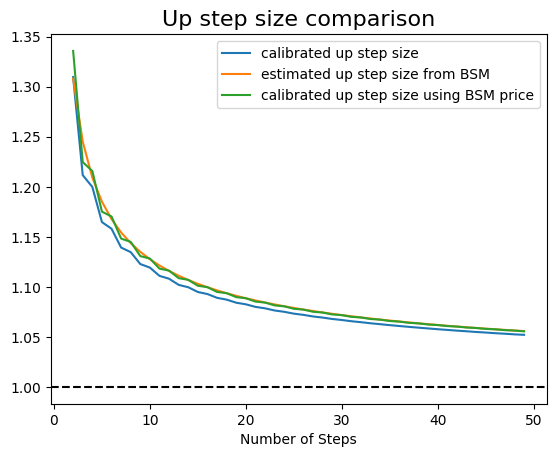

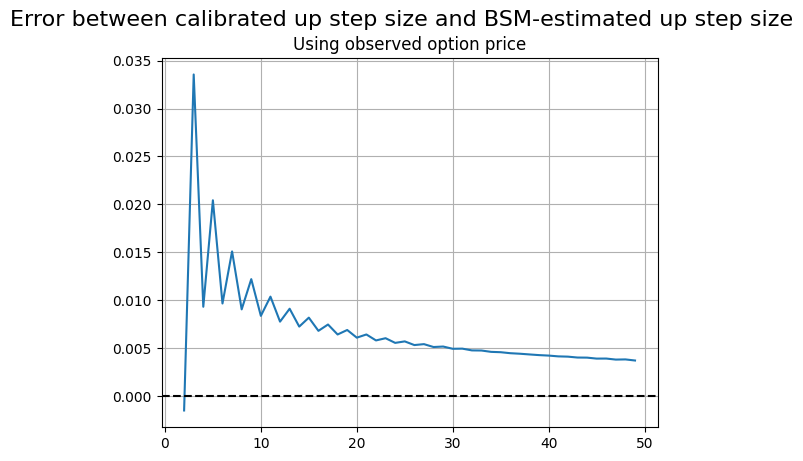

Text(0.5, 1.0, 'Using option price given by BSM')

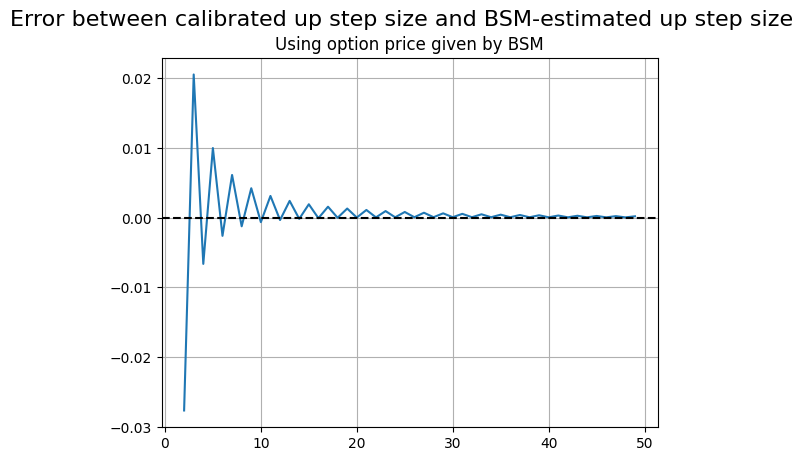

In [155]:
import matplotlib.pyplot as plt

steps_list = np.arange(2, 50) # Excluding 1 for better visualization
spot_mult_up_calibrated = []
spot_mult_up_calibrated_bsm_price = []
for steps in steps_list:
    spot_mult_up_calibrated += [calibrate(spot, K, T, c, annual_discount_factor, steps).root]
    spot_mult_up_calibrated_bsm_price += [calibrate(spot, K, T, c_BSM, annual_discount_factor, steps).root]
spot_mult_up_calibrated = np.array(spot_mult_up_calibrated)
spot_mult_up_calibrated_bsm_price = np.array(spot_mult_up_calibrated_bsm_price)
BSM_spot_mult_up = np.array([np.exp(vol * np.sqrt(T / N)) for N in steps_list])

plt.plot(steps_list, spot_mult_up_calibrated, label='calibrated up step size')
plt.plot(steps_list, BSM_spot_mult_up, label='estimated up step size from BSM')
plt.plot(steps_list, spot_mult_up_calibrated_bsm_price, label='calibrated up step size using BSM price')
plt.axhline(1, color='black', linestyle='--')
plt.title('Up step size comparison', fontsize=16)
plt.xlabel('Number of Steps')
plt.legend()
plt.show()

error = BSM_spot_mult_up - spot_mult_up_calibrated
plt.plot(steps_list, error)
plt.axhline(0, color='black', linestyle='--')
plt.grid()
plt.suptitle('Error between calibrated up step size and BSM-estimated up step size', fontsize=16)
plt.title('Using observed option price', fontsize=12)
plt.show()

error2 = BSM_spot_mult_up - spot_mult_up_calibrated_bsm_price
plt.plot(steps_list, error2)
plt.axhline(0, color='black', linestyle='--')
plt.grid()
plt.suptitle('Error between calibrated up step size and BSM-estimated up step size', fontsize=16)
plt.title('Using option price given by BSM', fontsize=12)

In [156]:
from scipy.stats import norm

def black_scholes_european_call(S0: float, K: float, T: float, sigma: float, r: float):
    d1 = ( np.log( S0 / K ) + ( r + 0.5 * sigma**2 ) * T ) / ( sigma * T**0.5 )
    d2 = d1 - sigma * T**0.5
    N_d1 = norm.cdf(d1)
    N_d2 = norm.cdf(d2)
    df = np.exp((-1.0)*r*T)
    return S0 * N_d1 - K * df * N_d2

## Strike price ($K$) is varied

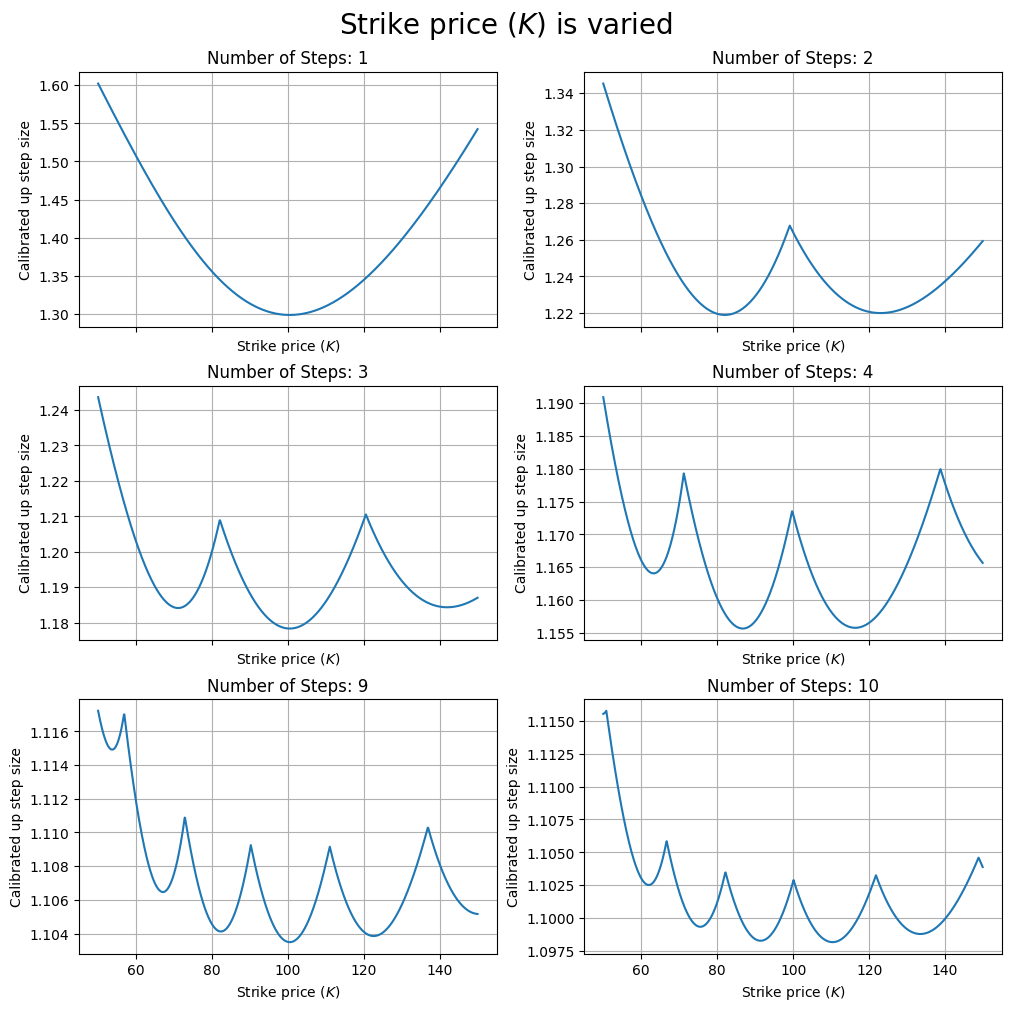

In [168]:
fig, ax = plt.subplots(3, 2, sharex='all', figsize=(10, 10), layout='constrained')
fig.suptitle('Strike price ($K$) is varied', fontsize=20)
ax = ax.flatten()

spot = 100
expiry = 1
rate = 0.05
annual_discount_factor = 1 / (1 + rate)
vol = 0.3
strike_vals = np.arange(50, 150, 0.1)

steps_vals = [1, 2, 3, 4, 9, 10]
for axis, steps in enumerate(steps_vals):
    spot_mult_up = np.zeros(len(strike_vals))
    for n, strike in enumerate(strike_vals):
        price = black_scholes_european_call(spot, strike, expiry, vol, rate)
        spot_mult_up[n] = calibrate(spot, strike, expiry, price, annual_discount_factor, steps).root

    ax[axis].plot(strike_vals, spot_mult_up)
    ax[axis].set_title(f'Number of Steps: {steps}')
    ax[axis].set_ylabel('Calibrated up step size')
    ax[axis].set_xlabel('Strike price ($K$)')
    ax[axis].grid(True)

plt.show()

## ITM option, expiry ($T$) is varied

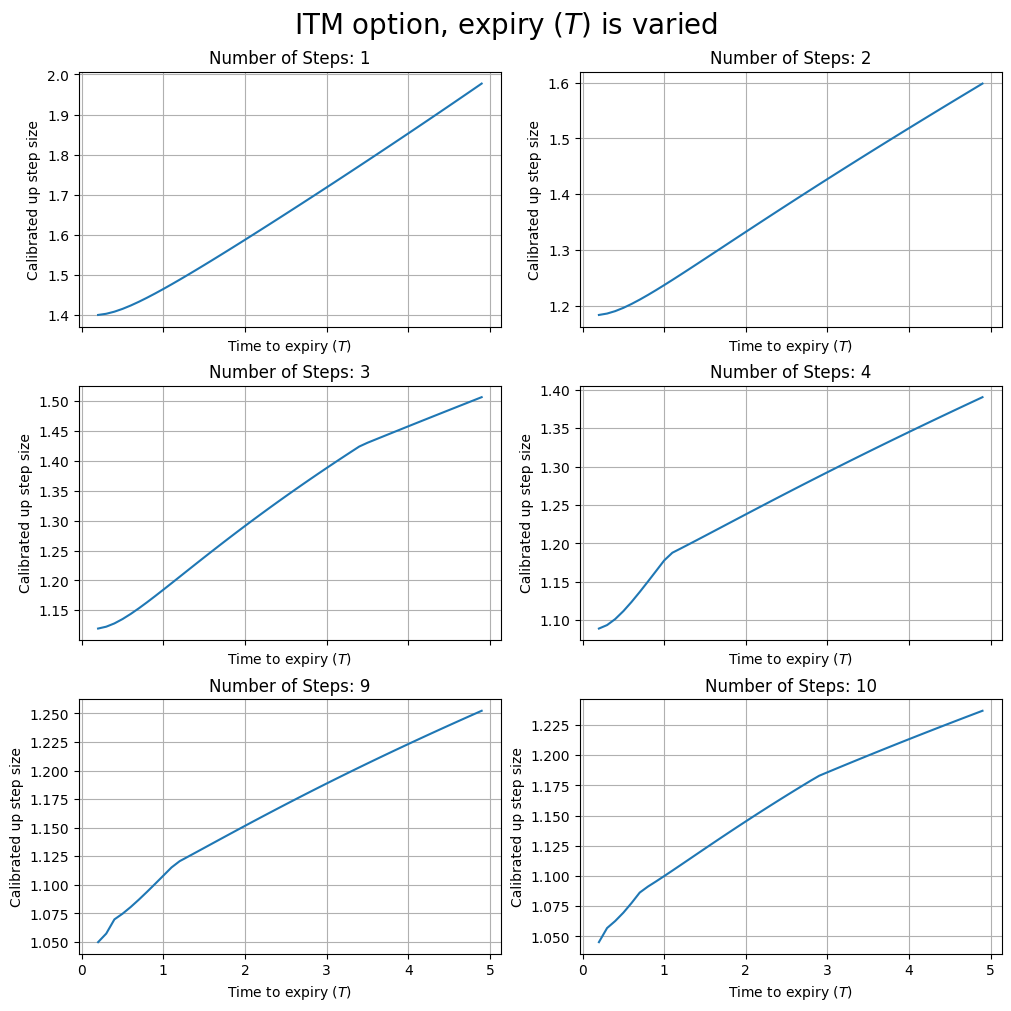

In [167]:
fig, ax = plt.subplots(3, 2, sharex='all', figsize=(10, 10), layout='constrained')
fig.suptitle('ITM option, expiry ($T$) is varied', fontsize=20)
ax = ax.flatten()

spot = 100
expiry_vals = np.arange(0.2, 5, 0.1)
rate = 0.05
annual_discount_factor = 1 / (1 + rate)
vol = 0.3
strike = 140

steps_vals = [1, 2, 3, 4, 9, 10]
for axis, steps in enumerate(steps_vals):
    spot_mult_up = np.zeros(len(expiry_vals))
    for n, expiry in enumerate(expiry_vals):
        price = black_scholes_european_call(spot, strike, expiry, vol, rate)
        spot_mult_up[n] = calibrate(spot, strike, expiry, price, annual_discount_factor, steps).root

    ax[axis].plot(expiry_vals, spot_mult_up)
    ax[axis].set_title(f'Number of Steps: {steps}')
    ax[axis].set_ylabel('Calibrated up step size')
    ax[axis].set_xlabel('Time to expiry ($T$)')
    ax[axis].grid(True)

plt.show()

## ATM option, expiry ($T$) is varied

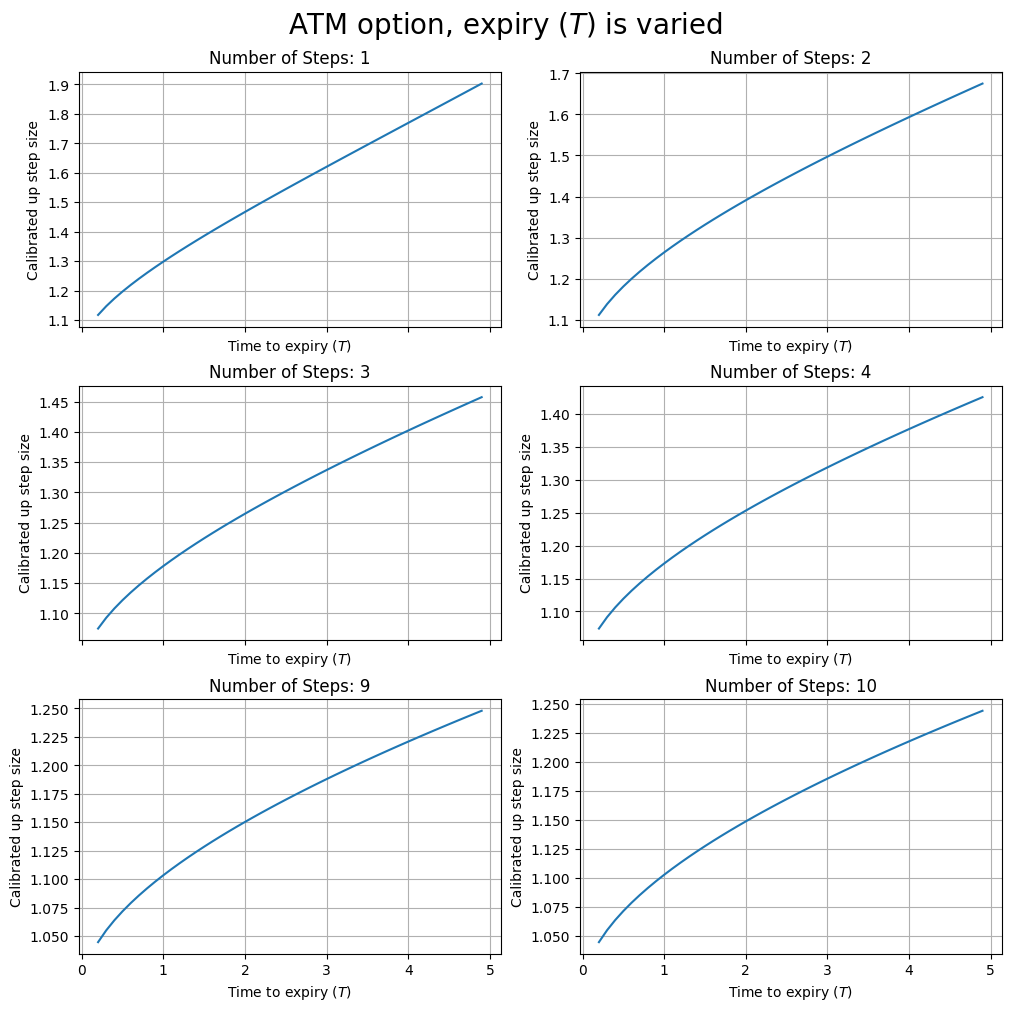

In [166]:
fig, ax = plt.subplots(3, 2, sharex='all', figsize=(10, 10), layout='constrained')
fig.suptitle('ATM option, expiry ($T$) is varied', fontsize=20)
ax = ax.flatten()

spot = 100
expiry_vals = np.arange(0.2, 5, 0.1)
rate = 0.05
annual_discount_factor = 1 / (1 + rate)
vol = 0.3
strike = 100

steps_vals = [1, 2, 3, 4, 9, 10]
for axis, steps in enumerate(steps_vals):
    spot_mult_up = np.zeros(len(expiry_vals))
    for n, expiry in enumerate(expiry_vals):
        price = black_scholes_european_call(spot, strike, expiry, vol, rate)
        spot_mult_up[n] = calibrate(spot, strike, expiry, price, annual_discount_factor, steps).root

    ax[axis].plot(expiry_vals, spot_mult_up)
    ax[axis].set_title(f'Number of Steps: {steps}')
    ax[axis].set_ylabel('Calibrated up step size')
    ax[axis].set_xlabel('Time to expiry ($T$)')
    ax[axis].grid(True)

plt.show()

## OTM option, expiry ($T$) is varied

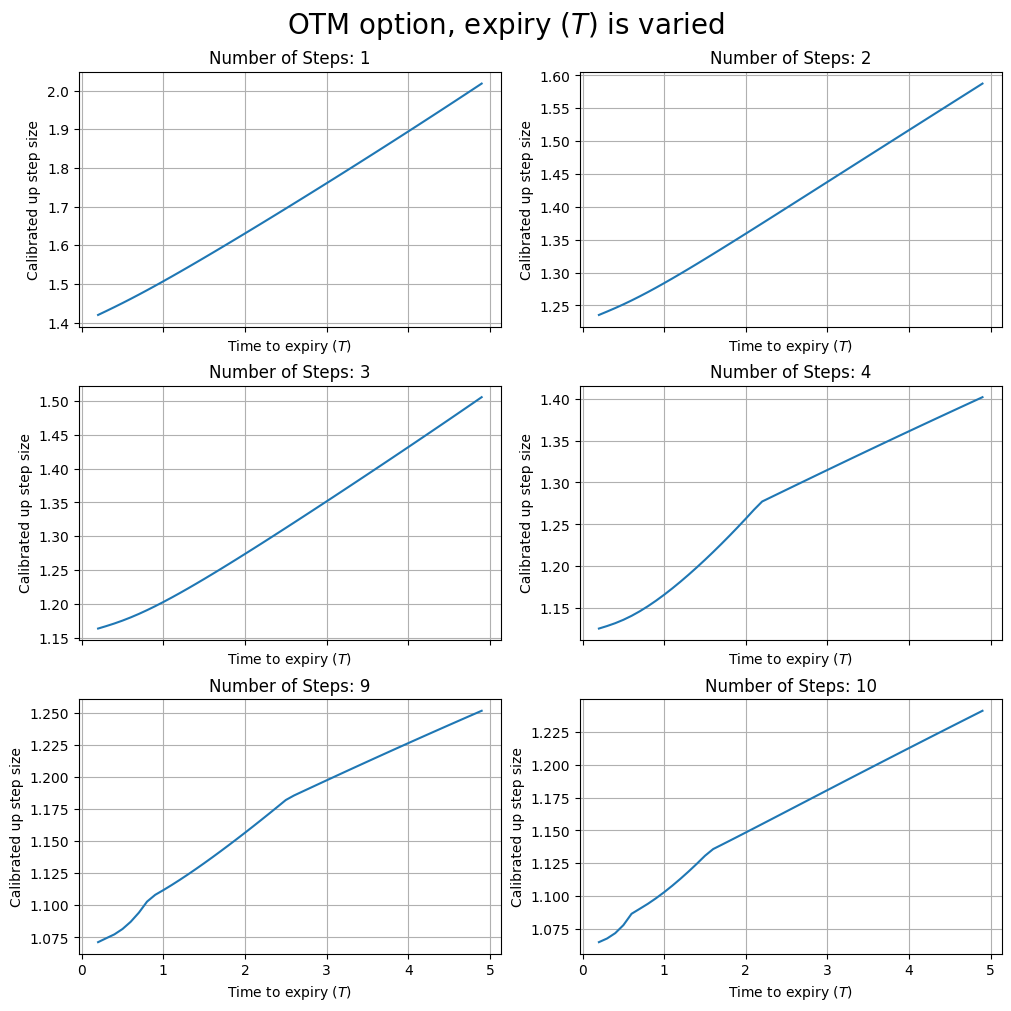

In [165]:
fig, ax = plt.subplots(3, 2, sharex='all', figsize=(10, 10), layout='constrained')
fig.suptitle('OTM option, expiry ($T$) is varied', fontsize=20)
ax = ax.flatten()

spot = 100
expiry_vals = np.arange(0.2, 5, 0.1)
rate = 0.05
annual_discount_factor = 1 / (1 + rate)
vol = 0.3
strike = 60

steps_vals = [1, 2, 3, 4, 9, 10]
for axis, steps in enumerate(steps_vals):
    spot_mult_up = np.zeros(len(expiry_vals))
    for n, expiry in enumerate(expiry_vals):
        price = black_scholes_european_call(spot, strike, expiry, vol, rate)
        spot_mult_up[n] = calibrate(spot, strike, expiry, price, annual_discount_factor, steps).root

    ax[axis].plot(expiry_vals, spot_mult_up)
    ax[axis].set_title(f'Number of Steps: {steps}')
    ax[axis].set_ylabel('Calibrated up step size')
    ax[axis].set_xlabel('Time to expiry ($T$)')
    ax[axis].grid(True)

plt.show()